In [26]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [27]:
files = os.listdir("data/Labels")
colors = set()
for i, fname in enumerate(files, 1):
    img = np.array(Image.open(f"data/Labels/{fname}").convert("RGB")).reshape(-1, 3)
    for color in map(tuple, np.unique(img, axis=0)):
        colors.add(color)
    print(f"{i}/{len(files)} ({100*i//len(files)}%) - {len(colors)} colors found", end="\r")
    if len(colors) == 12:
        print(f"\nAll 12 classes found after {i} images!")
        break

print()
for c in sorted(colors):
    print(c)

214/33699 (0%) - 12 colors found
All 12 classes found after 214 images!

(np.uint8(0), np.uint8(0), np.uint8(0))
(np.uint8(0), np.uint8(0), np.uint8(255))
(np.uint8(0), np.uint8(127), np.uint8(255))
(np.uint8(0), np.uint8(255), np.uint8(0))
(np.uint8(0), np.uint8(255), np.uint8(127))
(np.uint8(0), np.uint8(255), np.uint8(255))
(np.uint8(127), np.uint8(0), np.uint8(255))
(np.uint8(127), np.uint8(255), np.uint8(0))
(np.uint8(255), np.uint8(0), np.uint8(0))
(np.uint8(255), np.uint8(0), np.uint8(255))
(np.uint8(255), np.uint8(127), np.uint8(0))
(np.uint8(255), np.uint8(255), np.uint8(0))


In [28]:
COLOR_MAP = {
    (255, 0,   0):   "UN",  # Red            – Unproductive
    (255, 127, 0):   "PA",  # Orange         – Pastureland
    (255, 255, 0):   "SH",  # Yellow         – Shrub grass
    (127, 255, 0):   "FO",  # Yellow-green   – Forest
    (0,   255, 0):   "BU",  # Lime green     – Buildings and urban area
    (0,   255, 127): "AR",  # Spring green   – Arable Land
    (255, 0,   255): "GR",  # Magenta        – Grass with trees
    (0,   255, 255): "RO",  # Cyan           – Roads
    (0,   127, 255): "WA",  # Light blue     – Water
    (0,   0,   255): "FR",  # Blue           – Fruits and nuts
    (127, 0,   255): "VI",  # Violet         – Vineyard
    (0,   0,   0):   "OT",  # Black          – Other
}

In [29]:
def draw_segmentation(image_path, label_path, selected_classes=None, alpha=0.2):
    img = np.array(Image.open(image_path))
    label = np.array(Image.open(label_path).convert("RGB"))

    if len(img.shape) == 2:
        img = np.stack([img, img, img], axis=-1)

    colored_mask = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)

    for color_rgb, class_name in COLOR_MAP.items():
        if selected_classes is None or class_name in selected_classes:
            mask = np.all(label == color_rgb, axis=-1)
            colored_mask[mask] = color_rgb

    blended = img.copy()
    mask_pixels = np.any(colored_mask > 0, axis=-1)
    blended[mask_pixels] = (alpha * colored_mask[mask_pixels] + (1 - alpha) * img[mask_pixels]).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(colored_mask)
    axes[1].set_title('Segmentation Mask')
    axes[1].axis('off')

    axes[2].imshow(blended)
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    present_classes = [
        class_name for color_rgb, class_name in COLOR_MAP.items()
        if np.any(np.all(label == color_rgb, axis=-1))
    ]
    print(f'Classes in this image: {present_classes}')

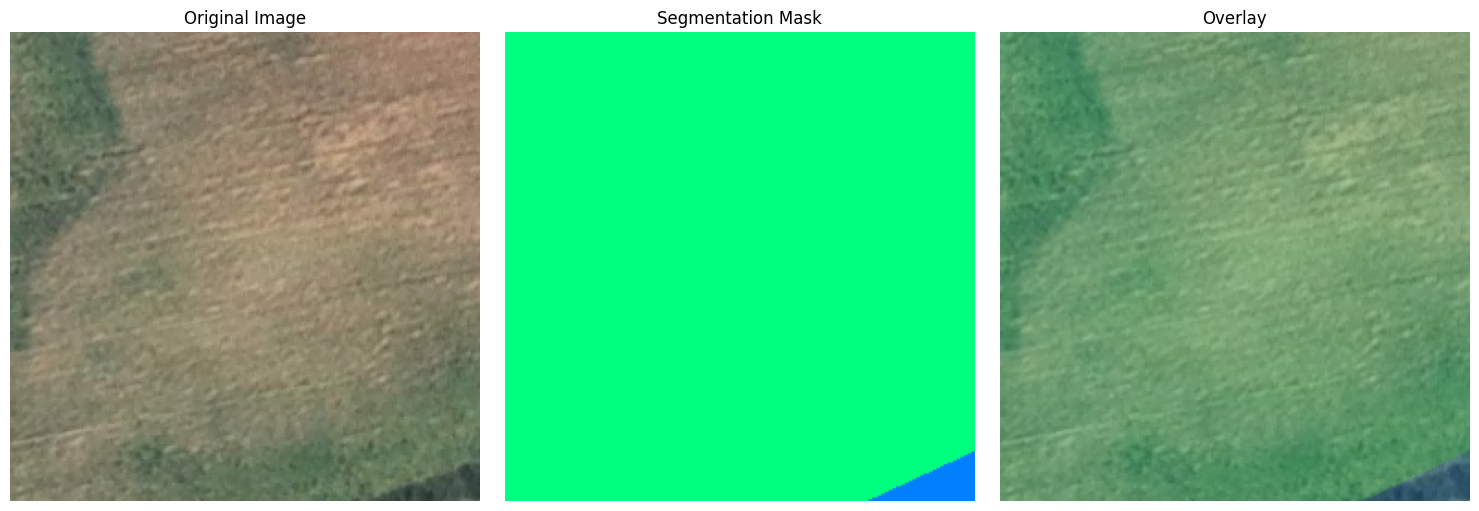

Classes in this image: ['AR', 'WA']


In [30]:
image_name = '0199_1_001_029.tif'
classes_to_show = None  

draw_segmentation(
    f'data/Images/{image_name}',
    f'data/Labels/{image_name}',
    selected_classes=classes_to_show
)